First Five Rows:
        Car_Name  Year  Selling_Price_Lakh  Present_Price_Lakh  Kms_Driven  \
0    Maruti Alto  2019                 3.5                 5.0       22000   
1    Hyundai i20  2020                 6.2                 8.0       18000   
2     Honda City  2018                 8.5                12.0       30000   
3  Toyota Innova  2017                14.0                20.0       45000   
4   Maruti Swift  2021                 5.8                 7.5       12000   

  Fuel_Type Seller_Type Transmission  Good_Resale  
0    Petrol      Dealer       Manual            1  
1    Petrol      Dealer       Manual            1  
2    Petrol      Dealer       Manual            1  
3    Diesel      Dealer       Manual            1  
4    Petrol  Individual       Manual            1  

Dataset Shape:
(30, 9)

Statistical Summary:
              Year  Selling_Price_Lakh  Present_Price_Lakh    Kms_Driven  \
count    30.000000           30.000000           30.000000     30.000000   
mean

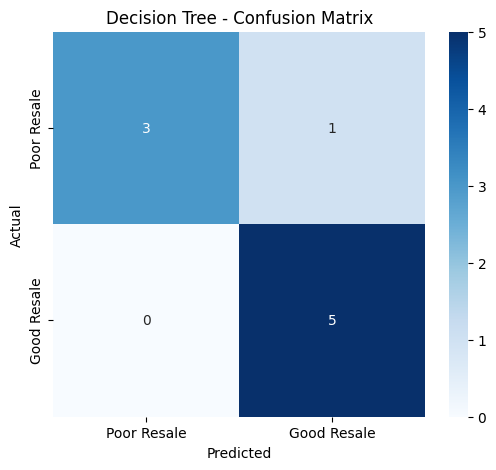

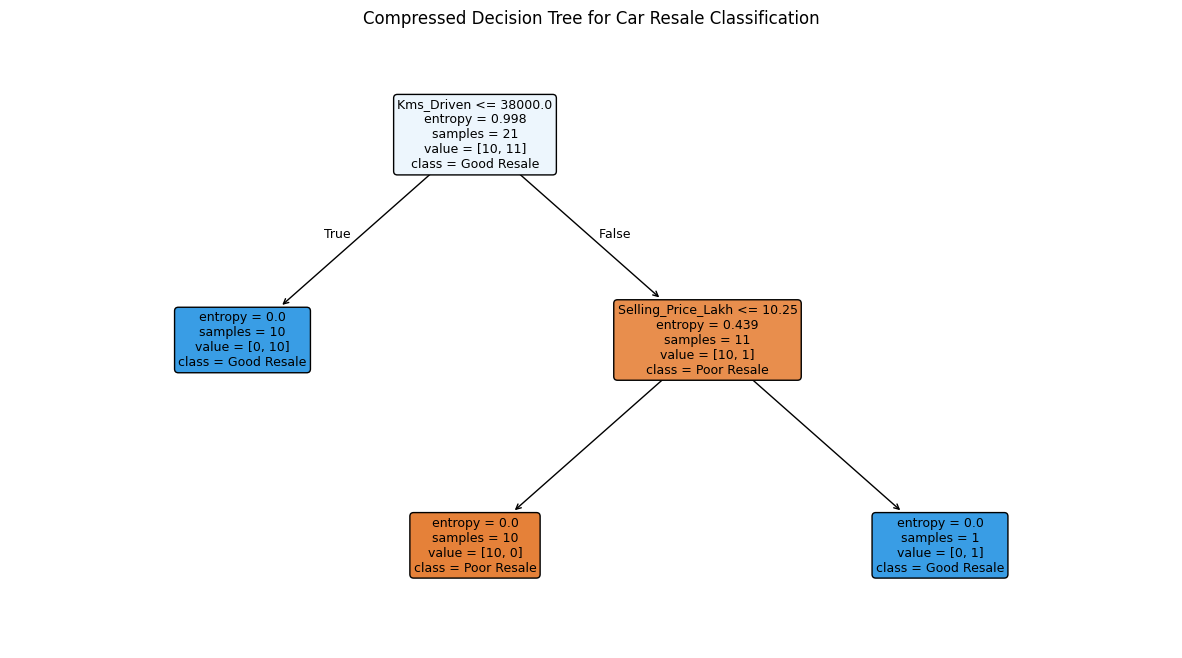


Feature Importance:
              Feature  Importance
4          Kms_Driven     0.76941
2  Selling_Price_Lakh     0.23059
1                Year     0.00000
0            Car_Name     0.00000
3  Present_Price_Lakh     0.00000
5           Fuel_Type     0.00000
6         Seller_Type     0.00000
7        Transmission     0.00000


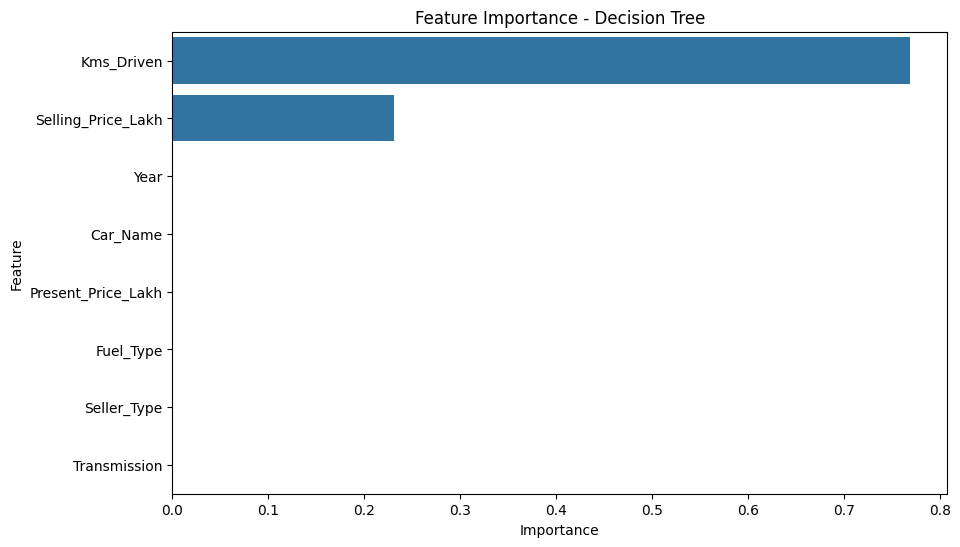

In [ ]:

# IMPLEMENT DECISION TREE LEARNING ALGORITHM
# ON CAR DATASET
# EVALUATE USING ACCURACY, PRECISION



# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score
)



# LOAD THE DATASET


df = pd.read_csv('/content/car_decision_tree_dataset.csv')

print("First Five Rows:")
print(df.head())


# DATASET SHAPE


print("\nDataset Shape:")
print(df.shape)


# STATISTICAL SUMMARY


print("\nStatistical Summary:")
print(df.describe())


# DATASET INFORMATION


print("\nDataset Information:")
df.info()


# CHECK DUPLICATE ROWS


print("\nNo of duplicate rows:")
print(df.duplicated().sum())



# CHECK MISSING VALUES

print("\nMissing Values:")
print(df.isnull().sum())


# FEATURE SUMMARY


numerical_features = df.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_features = df.select_dtypes(
    include=['object']
).columns

print("\nFeature Summary:")

print("\nNumerical Features:")
for col in numerical_features:
    print("-", col)

print("\nCategorical Features:")
for col in categorical_features:
    print("-", col)


# ENCODE CATEGORICAL FEATURES


le = LabelEncoder()

df['Car_Name'] = le.fit_transform(df['Car_Name']) # Add this line to encode Car_Name
df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
df['Seller_Type'] = le.fit_transform(df['Seller_Type'])
df['Transmission'] = le.fit_transform(df['Transmission'])

print("\nCategorical features encoded successfully")


# SEPARATE FEATURES AND TARGET


X = df.drop('Good_Resale', axis=1)
y = df['Good_Resale']

print("\nFeatures (X) and Target (y) separated successfully")


# SPLIT DATASET INTO TRAINING AND TESTING SETS

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("\nDataset successfully split into training and testing sets")
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


# MODEL BUILDING
# COMPRESSED DECISION TREE

model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

print("\nDecision Tree model trained successfully")


# PREDICTIONS

y_pred = model.predict(X_test)

print("\nPredictions:")
print(y_pred)


# CONFUSION MATRIX


cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# CLASSIFICATION REPORT

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Poor Resale', 'Good Resale']
))


# ACCURACY

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy: {:.2f}%".format(
    accuracy * 100
))


# PRECISION

precision = precision_score(y_test, y_pred)

print("Precision: {:.2f}%".format(
    precision * 100
))


# TRAINING ACCURACY

train_accuracy = model.score(X_train, y_train)

print("\nTraining Accuracy: {:.2f}%".format(
    train_accuracy * 100
))


# TESTING ACCURACY

test_accuracy = model.score(X_test, y_test)

print("Testing Accuracy: {:.2f}%".format(
    test_accuracy * 100
))


# CONFUSION MATRIX VISUALIZATION

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Poor Resale', 'Good Resale'],
    yticklabels=['Poor Resale', 'Good Resale']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")

plt.show()


# DISPLAY COMPRESSED DECISION TREE

from sklearn import tree

plt.figure(figsize=(15, 8))

tree.plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Poor Resale', 'Good Resale'],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Compressed Decision Tree for Car Resale Classification")

plt.show()


# FEATURE IMPORTANCE

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)


# FEATURE IMPORTANCE VISUALIZATION

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()